## mnist nueral net
-------------------

a notebook to inspect the results of my locally built neural net for the mnist task.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data.mnist import load_mnist
from nn.activations import ReLU
from nn.checkpoint import load_checkpoint
from nn.layers import Dense
from nn.model import Sequential

In [6]:
def build_model(seed: int = 0) -> Sequential:
    """
    builds the multi-layer perceptron for my mnist task.
    this returns the untrained model with the training architecture.
    """
    rng = np.random.default_rng(seed)
    return Sequential(
        [
            Dense(784, 256, rng=rng),
            ReLU(),
            Dense(256, 10, rng=rng),
        ]
    )


def softmax(logits: np.ndarray) -> np.ndarray:
    """
    for computing some softmax probabilities.
    """
    shifted = logits - logits.max(axis=-1, keepdims=True)
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum(axis=-1, keepdims=True)

In [ ]:
model = build_model()
load_checkpoint(model, Path("artifacts/mlp_mnist.npz"))

x_train, y_train, x_test, y_test = load_mnist(flatten=True, normalise=True)
x_test_img = x_test.reshape(-1, 28, 28)

print(x_test.shape, y_test.shape)

(10000, 784) (10000,)


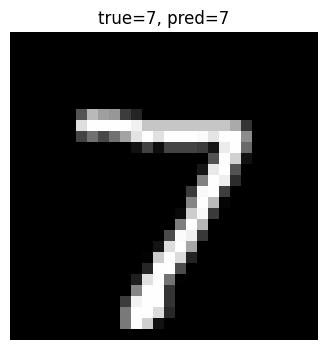

probabilities: [0.000e+00 0.000e+00 1.000e-04 5.400e-03 0.000e+00 1.000e-04 0.000e+00
 9.942e-01 0.000e+00 2.000e-04]


In [4]:
idx = 0

img = x_test_img[idx]
x = x_test[idx:idx + 1]
y_true = int(y_test[idx])

logits = model.forward(x)
probs = softmax(logits)[0]
y_pred = int(np.argmax(probs))

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title(f"true={y_true}, pred={y_pred}")
plt.axis("off")
plt.show()

print("probabilities:", np.round(probs, 4))